In [8]:
import numpy as np
from datetime import date
from scipy import io as sio
import h5py
from scipy import ndimage
import time
import argparse
import xarray as xr
from scipy.ndimage import label

## Descriptions

After KNN smoothing, now you can start MHW event tracking! 

Follow the sections 
1. functions,
2. setting
3. mask
4. load (previous) tracks
5. Main function
6. visualization


## Tracking-related Functions

In [31]:
import ast
# The function to load previous MHW tracks and search data
def read_old_MHW_tracks_and_search_from_txtfile(oldtrackfile, oldsearchfile):
    track_output = oldtrackfile
    search_output = oldsearchfile
   
    # Open the file and read its contents
    with open(track_output+".txt", 'r') as file:
        lines = file.readlines()
    # Convert each line (which is a dictionary string) into a dictionary using ast.literal_eval()
    oldtracks = [ast.literal_eval(line.strip()) for line in lines if line.strip()]
    print("tracks: ",len(oldtracks))

    
    # Open the file and read its contents
    with open(search_output+".txt", 'r') as file:
        lines = file.readlines()
    # Convert each line (which is a dictionary string) into a dictionary using ast.literal_eval()
    oldsearch = [ast.literal_eval(line.strip()) for line in lines if line.strip()]
    print("search: ",len(oldsearch))
    return oldsearch, oldtracks

In [ ]:
# The function to extend mask for circular tracking over global ocean (## regional ocean doesn't need this!)
def extend_map_and_mask_repeated_area(mhw_3dmask):
    # Extend the mask map from 100W-70W
    mhw_3dmask_copy = mhw_3dmask.copy()
    mhw_3dmask_copy['lon'] = 360-(-mhw_3dmask_copy['lon'])  
    
    mhw_3dmask_east180 = mhw_3dmask_copy.sel(lon=slice(180,290))
    mhw_3dmask_west180 = mhw_3dmask.sel(lon=slice(-99.5,180))
    
    mhw_3dmask_full = xr.concat([mhw_3dmask_west180, mhw_3dmask_east180], dim='lon')
    #mhw_3dmask_full[0][0].plot()

    # mask the repeated area to be no mhw
    mhw_3dmask_full.loc[dict(lon=slice(-100, -90), lat=slice(15, 18))] =0
    mhw_3dmask_full.loc[dict(lon=slice(-100, -85), lat=slice(10, 15))] = 0
    mhw_3dmask_full.loc[dict(lon=slice(-100, -70), lat=slice(-65, 10))] = 0
    mhw_3dmask_full.loc[dict(lon=slice(260, 290), lat=slice(18, 65))] = 0
    mhw_3dmask_full.loc[dict(lon=slice(270, 290), lat=slice(15, 18))] = 0
    mhw_3dmask_full.loc[dict(lon=slice(275, 290), lat=slice(10, 15))] = 0
    mhw_3dmask_full[0][0].plot()
    return mhw_3dmask_full

In [33]:
# The function to prepare MHW mask for tracking 
def data_load (current_year, mhw_mask): 
    # Transform MHW mask on land grid from "nan" to be "0" (no MHW). 
    my_mhw_mask = np.nan_to_num(mhw_mask, nan=0) 
    return my_mhw_mask

In [34]:
# The function to create a 3D binary MHW mask with a given shape and interested location index
def put_mhw_in_mesh(dims: tuple, x, y, z): 
    mesh_mhw = np.zeros(dims)
    mesh_mhw[x, y, z] = 1
    return mesh_mhw

In [35]:
import numpy as np
import xarray as xr
from scipy.ndimage import label
# The function to check connectivity of MHW objects on two sides of 70W
def manually_check_connected_mhws_around70W(monthind,labelmask, depths, latitudes, longitudes):
    D1 = xr.DataArray(labelmask, coords=dict(depths=depths, lat=latitudes, lon=longitudes))

    # Extract eastern and western boundary slices
    eastmost = D1.sel(lon=289.5, lat=slice(-59.5, -53.5)).values
    westmost = D1.sel(lon=-69.5, lat=slice(-59.5, -53.5)).values

    # Stack and create binary mask for connected components
    boundary_stack = np.stack([eastmost, westmost], axis=0)
    binary_mask = (boundary_stack != 0).astype(np.uint8)

    # Label connected components in the binary mask
    D3, N3 = label(binary_mask)
    updatedD1 = D1.values.copy()

    if N3 == 0:
        #print("No found MHWs!")
        return updatedD1, np.unique(updatedD1).shape[0]

    for label_n in range(1, N3 + 1):
        #print("Current label:", label_n)
        x, z, y = np.where(D3 == label_n)

        if np.any(x == 0) and np.any(x == 1):  # Connected east and west
            westlabels = np.unique(westmost[z[x == 0], y[x == 0]])
            eastlabels = np.unique(eastmost[z[x == 1], y[x == 1]])

            # Filter non-zero labels
            westnozerolabels = westlabels[westlabels != 0]
            eastnozerolabels = eastlabels[eastlabels != 0]

            if len(westnozerolabels) == 0 or len(eastnozerolabels) == 0:
                continue

            newlabel = westnozerolabels.min()
            print("month order", monthind)
            print("MHWs around 70W are connected! West:", westnozerolabels, "East:", eastnozerolabels, "→ new label:", newlabel)

            # Efficient in-place relabeling using NumPy
            mask_east = np.isin(updatedD1, eastnozerolabels)
            updatedD1[mask_east] = newlabel

            mask_west = np.isin(updatedD1, westnozerolabels)
            updatedD1[mask_west] = newlabel
        

    # Normalize labels to be continuous
    unique_vals = np.unique(updatedD1)
    updatedD1_continuous = np.searchsorted(unique_vals, updatedD1)
    updatedN = unique_vals.shape[0]

    print("Initial Total labels:", np.unique(D1).shape[0])
    print("Updated Total labels:", updatedN)

    return updatedD1_continuous, updatedN


In [36]:
import numpy as np
from scipy.ndimage import label
# The function to label MHW objects and filter small volume MHWs
def make_MHWs(mhw_mask, month_count, judgement,depths, latitudes, longitudes, threshold):
    print("Identifying MHW objects analysis start.")

 # Calculate every latitude and 1 longitude grid distance (km) 
    earth_radius = 6378.137  # km
    pi180 = np.pi / 180
    latitudes_rad = latitudes * pi180
    lat_half_diff = 0.5 * pi180
    lat_band_height = earth_radius * (np.sin(latitudes_rad + lat_half_diff) - np.sin(latitudes_rad - lat_half_diff))  # km
    lon_band_width = earth_radius * pi180 * np.cos(latitudes_rad)
    # Calculate every depth level distance (km)
    grid_thickness = np.insert(np.diff(depths), 0, depths[0]) * 1e-3  # km
    
    #Specify your volume threshold and region threshold 
    volume_threshold = 1.0732e+04 * 5 * 1e-3 * 1000  # volume threshold: 1-by-1 degree grid area (km2) * grid depth space (km) * number of grid (here, I secify 1000 grid cells at 30° and each grid cell has 5m thickness)
    region_threshold = 1000 # region threshold: number of local grids

    time_steps = mhw_mask.shape[0]
    MHWs = []
    #Loop over each time step
    for month in range(time_steps):
        # label each 3D connected MHW object
        cal_mask = mhw_mask[month]  # dims: depth, lat, lon
        D1, N = label(cal_mask)
        monthind = month+month_count
        # Manually check if the MHW objects on west and east sides of 70W are connected. Yes-> one object, No-> two objects
        updateD1, updateN = manually_check_connected_mhws_around70W(monthind, D1, depths, latitudes, longitudes)

        mhw_dict = dict(month= month + month_count, zloc= [], yloc= [], xloc= [])
        
        # For each object, record its index of 3D dimensions. 
        for label_id in range(1, updateN + 1):
            z, y, x = np.where(updateD1 == label_id)
            # judge whether its size (volume or region) exceeds the threshold
            if judgement == 'volume':
                # Vectorized volume calculation
                lat_distances = lat_band_height[y]
                thicknesses = grid_thickness[z]
                lon_distances = lon_band_width[y]
                volumes = lon_distances * lat_distances * thicknesses
                total_volume = np.sum(volumes)

                if total_volume >= volume_threshold:
                    mhw_dict['zloc'].append(z.tolist())
                    mhw_dict['yloc'].append(y.tolist())
                    mhw_dict['xloc'].append(x.tolist())

            elif judgement == 'region':
                if z.size >= region_threshold:
                    mhw_dict['zloc'].append(z.tolist())
                    mhw_dict['yloc'].append(y.tolist())
                    mhw_dict['xloc'].append(x.tolist())

            else:
                raise ValueError("Invalid mhws judgment method value provided. Use 'volume' or 'region'.")

        MHWs.append(mhw_dict) # It contains all MHW object 3D information for all time steps.

    return MHWs


In [37]:
import numpy as np
# The function to judge if two MHWs from adjacent times overlap exceed the threshold 
def mapping(t1_loc, t2_loc, longitudes, latitudes, depths, alpha):
    # Precompute constants
    grid_shape = (len(longitudes), len(latitudes), len(depths))  #3D global ocean tuple (x,y,z)
    n_t1 = len(t1_loc)# number of MHW objects at previous time
    n_t2 = len(t2_loc)# number of MHW objuects at current time

    # Initialize the mapping matrix between MHW objects at two time
    mapping_t1_t2 = np.zeros((n_t1, n_t2), dtype=np.uint8)

    # Generate global binary masks for each MHW object at two time (objects->1, no object->0)
    t1_masks = [
        put_mhw_in_mesh(grid_shape, t1['xloc'][0], t1['yloc'][0], t1['zloc'][0]).astype(np.bool_)
        for t1 in t1_loc
    ] # previous time
    t2_masks = [
        put_mhw_in_mesh(grid_shape, t2['xloc'][0], t2['yloc'][0], t2['zloc'][0]).astype(np.bool_)
        for t2 in t2_loc
    ] # current time

    # compute grid size for each MHW object for two times 
    t1_sizes = [np.sum(mask) for mask in t1_masks]
    t2_sizes = [np.sum(mask) for mask in t2_masks]

    # Compute the overlapping ratio between each pair of MHW objects from current and presious time
    # if the ratio >= threshold, then assign 1 to the mapping matrix, otherwise, keep it 0.
    for i, t1_mask in enumerate(t1_masks):
        for j, t2_mask in enumerate(t2_masks):
            intersection = np.sum(np.logical_and(t1_mask, t2_mask))
            denom = min(t1_sizes[i], t2_sizes[j])
            if denom > 0:
                overlap_ratio = intersection / denom
                if overlap_ratio >= alpha:
                    mapping_t1_t2[i, j] = 1

    return mapping_t1_t2


In [38]:
import numpy as np
# The function to append the current-time 4D information of MHW objects for those continuous MHW tracks.
def simple_and_spliting(mapping_t1_t2, search, x, y, z, month):
    # t1_idx: the index of MHW objects at previous time (t1) that overlap with any MHW object at current time (t2)
    t1_idx = np.flatnonzero(np.any(mapping_t1_t2, axis=1))
    # loop over the overlapped MHW objects at previous time (t1)
    for idx_1 in t1_idx:
        # t2_idx: the index of MHW object at current time (t2) that overlaps with the idx_1 MHW object at previous time (t1)
        t2_idx = np.flatnonzero(mapping_t1_t2[idx_1])

        temp_mhw_x = []
        temp_mhw_y = []
        temp_mhw_z = []
        # Loop over the associated MHW objects at current time (t2)
        for idx_2 in t2_idx:
            # load the 3D informaton of current MHW object
            temp_mhw_x.extend(x[idx_2]) #x[idx_2]: longitude index of idx_2 MHW object at current time
            temp_mhw_y.extend(y[idx_2]) # laitude index
            temp_mhw_z.extend(z[idx_2]) # depth index

        # Find the 4D data for the overlapped MHW object at previous time 
        search_entry = search[idx_1]
        # Append the 3D information of associated MHW object at current time
        search_entry['month'].append(month)
        search_entry['xloc'].append(temp_mhw_x)
        search_entry['yloc'].append(temp_mhw_y)
        search_entry['zloc'].append(temp_mhw_z)

    return search


In [39]:
import numpy as np
import scipy.ndimage as ndimage

# The function to deal with the condition when multiple previous-time MHW objects overlap with 1 current-time MHW object ("MHW merging")
# Solution: split the current-time MHW object into parts that belong to different MHW tracks, based on center distances. 
def merging(mapping_t1_t2, search, loc_now, longitudes, latitudes, depths):
    
    # t2_idx: the index of the MHW objects in current time (t2) that overlap with any MHW objects in previous time (t1)
    t2_idx = np.where(np.sum(mapping_t1_t2, axis=0) > 1)[0]
    if len(t2_idx) == 0: # there is no overlapped objects
        return search

    print("merging analysis start")
    print(len(t2_idx), "is merged from previous mhws")

    shape = (len(longitudes), len(latitudes), len(depths))
    pi180 = np.pi / 180
    earth_radius = 6378.137
    
    # Loop over overlapped MHW object in current time 
    for idx_2 in t2_idx:
        # t1_idx: the index of MHW objects in previous time (t1) that overlapped with the idx_2 MHW object
        t1_idx = np.where(mapping_t1_t2[:, idx_2] > 0)[0]
        # load idx_2 MHW object 3D information at current time
        include_x, include_y, include_z = [np.array(loc_now[idx_2][key][0]) for key in ('xloc', 'yloc', 'zloc')]
        mean_x, mean_y, mean_z = [], [], []

        # Identify meshes and shared points for all t1_idx
        for idx_1, value_1 in enumerate(t1_idx):
            x_prev, y_prev, z_prev = search[value_1]['xloc'][-2], search[value_1]['yloc'][-2], search[value_1]['zloc'][-2]
            x_now, y_now, z_now = search[value_1]['xloc'][-1], search[value_1]['yloc'][-1], search[value_1]['zloc'][-1]
            past_2d = put_mhw_in_mesh(shape, x_prev, y_prev, z_prev)
            now_2d = put_mhw_in_mesh(shape, x_now, y_now, z_now)
            shared = np.logical_and(past_2d, now_2d)
            shared_idx = np.where(shared)

            # Use structured array for fast comparison
            t2_points = np.core.records.fromarrays([include_x, include_y, include_z], names='x,y,z')
            shared_points = np.core.records.fromarrays(shared_idx, names='x,y,z')
            _, match_idx_t2, _ = np.intersect1d(t2_points, shared_points, return_indices=True)

            # label the current MHW object grid with associated unqiue number for each idx_1
            include_x[match_idx_t2] = -(idx_1 + 1)
            include_y[match_idx_t2] = -(idx_1 + 1)
            include_z[match_idx_t2] = -(idx_1 + 1)
            
            # find the mean locations of idx_1 object
            mean_x.append(np.mean(x_prev))
            mean_y.append(np.mean(y_prev))
            mean_z.append(np.mean(depths[np.array(z_prev).flatten()]))

        others = np.where(include_x >= 0)[0]
        if others.size > 0:
            include_x_0 = include_x[others]
            include_y_0 = include_y[others]
            include_z_0 = include_z[others]
            depth_vals = depths[include_z_0]

            mean_x_arr = np.array(mean_x)
            mean_y_arr = np.array(mean_y)
            mean_z_arr = np.array(mean_z)

            lon_diff = (include_x_0[:, None] - mean_x_arr) * earth_radius * pi180
            lat_diff = (np.sin(include_y_0[:, None] * pi180) - np.sin(mean_y_arr * pi180)) * earth_radius
            depth_diff = (depth_vals[:, None] - mean_z_arr) * 1e-3

            distance = np.sqrt(lon_diff**2 + lat_diff**2 + depth_diff**2)
            min_distance = np.argmin(distance, axis=1)

            assign_val = -(min_distance + 1)
            include_x[others] = include_y[others] = include_z[others] = assign_val

        for idx_1, value_1 in enumerate(t1_idx):
            mask = (include_x == -(idx_1 + 1))
            new_x, new_y, new_z = include_x[mask], include_y[mask], include_z[mask]

            if len(new_x) == len(search[value_1]['xloc'][-1]):
                search[value_1]['xloc'][-1] = new_x.tolist()
                search[value_1]['yloc'][-1] = new_y.tolist()
                search[value_1]['zloc'][-1] = new_z.tolist()
            else:
                extract1 = put_mhw_in_mesh(shape, search[value_1]['xloc'][-1], search[value_1]['yloc'][-1], search[value_1]['zloc'][-1])
                extract2 = put_mhw_in_mesh(shape, loc_now[idx_2]['xloc'][0], loc_now[idx_2]['yloc'][0], loc_now[idx_2]['zloc'][0])

                mask1 = np.where((extract1 == 1) & (extract2 == 0))
                mask2 = np.where((extract1 == 1) & (extract2 == 1))
                id_include = np.where(mask)[0]

                search[value_1]['xloc'][-1] = np.concatenate((mask1[0], mask2[0][id_include])).tolist()
                search[value_1]['yloc'][-1] = np.concatenate((mask1[1], mask2[1][id_include])).tolist()
                search[value_1]['zloc'][-1] = np.concatenate((mask1[2], mask2[2][id_include])).tolist()

        structure = ndimage.generate_binary_structure(3, 2)
        for idx_1, value_1 in enumerate(t1_idx):
            mhw = put_mhw_in_mesh(shape, search[value_1]['xloc'][-1], search[value_1]['yloc'][-1], search[value_1]['zloc'][-1])
            labels, n_features = ndimage.label(mhw, structure)
            if n_features <= 1:
                continue

            sizes = ndimage.sum(mhw, labels, index=np.arange(1, n_features + 1))
            max_idx = np.argmax(sizes)

            for r in range(n_features):
                if r == max_idx:
                    continue
                conn = np.where(labels == (r + 1))

                for idx_11, value_11 in enumerate(t1_idx):
                    if idx_11 == idx_1:
                        continue

                    other_x = search[value_11]['xloc'][-1]
                    other_y = search[value_11]['yloc'][-1]
                    other_z = search[value_11]['zloc'][-1]

                    combined_x = other_x + conn[0].tolist()
                    combined_y = other_y + conn[1].tolist()
                    combined_z = other_z + conn[2].tolist()

                    other_mhw = put_mhw_in_mesh(shape, other_x, other_y, other_z)
                    combined_mhw = put_mhw_in_mesh(shape, combined_x, combined_y, combined_z)

                    _, orig_n = ndimage.label(other_mhw, structure)
                    _, new_n = ndimage.label(combined_mhw, structure)

                    if new_n <= orig_n:
                        search[value_11]['xloc'][-1] = combined_x
                        search[value_11]['yloc'][-1] = combined_y
                        search[value_11]['zloc'][-1] = combined_z

                        original_mhw = put_mhw_in_mesh(shape, search[value_1]['xloc'][-1], search[value_1]['yloc'][-1], search[value_1]['zloc'][-1])
                        remaining = np.where((original_mhw == 1) & (combined_mhw == 0))
                        search[value_1]['xloc'][-1] = remaining[0].tolist()
                        search[value_1]['yloc'][-1] = remaining[1].tolist()
                        search[value_1]['zloc'][-1] = remaining[2].tolist()
                        break

    return search


In [40]:
import numpy as np

def tracking(current_MHWs, month_count, search, longitudes, latitudes, depths, alpha, tracks):
    print("tracking analysis start.")
    # loop over time steps 
    for month_in_MHWs in range(len(current_MHWs)): 
        # load 4D information of MHW objects at current time
        current_month = current_MHWs[month_in_MHWs]['month'] # the month indice
        mhw_xloc = current_MHWs[month_in_MHWs]['xloc']# the longitude index of all MHW objects at this time step
        mhw_yloc = current_MHWs[month_in_MHWs]['yloc']# the latitude index of all MHW objects at this time step
        mhw_zloc = current_MHWs[month_in_MHWs]['zloc']# the depth index of all MHW objects at this time step
        print("month: ", month_in_MHWs + month_count)
        load_start = time.time()

        if month_count + current_month == 0: # if this is the first month of time series
            print("This is the first month.")
             # then load all MHW object 3D information into 'search' as unfinished tracks
            for each_mhw in range(len(mhw_xloc)):
                search_dict = dict(month=[current_month], xloc= [mhw_xloc[each_mhw]], 
                               yloc= [mhw_yloc[each_mhw]], zloc= [mhw_zloc[each_mhw]])
                search.append(search_dict)
            print(len(search), ' MHW tracks.')

        else:  # if this is subsequent months
            # then we need to compare MHW objects in two consecutive time steps
            print("month", month_count + current_month)
            # Prepare loc_now and loc_old
            loc_now = [dict(xloc=[mhw_xloc[i]], yloc= [mhw_yloc[i]], zloc= [mhw_zloc[i]]) for i in range(len(mhw_xloc))]#'loc_now': current MHW objects;
            loc_old = [dict(month= [search[i]['month'][-1]], xloc= [search[i]['xloc'][-1]], 
                        yloc= [search[i]['yloc'][-1]], zloc= [search[i]['zloc'][-1]]) for i in range(len(search))]# 'loc_old': previous MHW object at the last time step of its unfinished MHW track 

            # Overlapping conditions between MHWs from two consecutive months
            mapping_t1_t2 = mapping(t1_loc=loc_old, t2_loc=loc_now, longitudes=longitudes, 
                                     latitudes=latitudes, depths=depths, alpha=alpha)


            # Update the 4D informtion of continuous MHW tracks
            search = simple_and_spliting(mapping_t1_t2=mapping_t1_t2, search=search, x=mhw_xloc, 
                                         y=mhw_yloc, z=mhw_zloc, month=current_month)
            # Deal with tracks when multiple MHW merges
            search = merging(mapping_t1_t2=mapping_t1_t2, search=search, loc_now=loc_now, 
                             longitudes=longitudes, latitudes=latitudes, depths=depths)
            print(len(search), ' MHW tracks, after reducing the MHWs overlapped with those in the previous month.')

            # Identify overlapping and merged MHWs
            mapping_sums = np.sum(mapping_t1_t2, axis=0) # the number of current-time MHW objects that overlap with any previous-time MHW objects
            overlap_t2_idx = np.where(mapping_sums > 0)[0]
            merge_t2_idx = np.where(mapping_sums > 1)[0]
            print(str(len(overlap_t2_idx))+" MHWs are formed from previous MHWs, with"+str(len(merge_t2_idx))+" merged and "+str(len(overlap_t2_idx) - len(merge_t2_idx))+" splitted.")

            # Identify new MHW tracks
            new_mhw_indices = np.where(mapping_sums == 0)[0]
            new_mhw_xloc = [mhw_xloc[i] for i in new_mhw_indices]
            new_mhw_yloc = [mhw_yloc[i] for i in new_mhw_indices]
            new_mhw_zloc = [mhw_zloc[i] for i in new_mhw_indices]

            # Save new tracks into search
            if new_mhw_xloc:
                for new_track in range(len(new_mhw_xloc)):
                    search_dict = dict(month= [current_month], xloc= [new_mhw_xloc[new_track]], 
                                   yloc= [new_mhw_yloc[new_track]], zloc= [new_mhw_zloc[new_track]])
                    search.append(search_dict)
            print(len(search), ' MHW tracks, after adding the tracks of ', len(new_mhw_xloc), ' newly occurring MHWs.')

            # Identify and process completed MHWs
            moved = [search[mhw]['month'][-1] == current_month - 1 for mhw in range(len(search))]
            for mhw, is_moved in enumerate(moved):
                if is_moved:
                    # Sorting the MHW grid by depth, latitude, and longitude
                    for i in range(len(search[mhw]['zloc'])):
                        sorted_arrays = sorted(zip(search[mhw]['zloc'][i], search[mhw]['yloc'][i], search[mhw]['xloc'][i]), 
                                               key=lambda x: (x[0], x[1], x[2]))
                        search[mhw]['zloc'][i], search[mhw]['yloc'][i], search[mhw]['xloc'][i] = zip(*sorted_arrays)
                    tracks.append(search[mhw])

            # Remove completed MHWs
            search = [value for value, flag in zip(search, moved) if not flag]
            print(len(search), ' MHW tracks, after removing the tracks of ', len(np.where(moved)[0]), ' completed MHWs.\n')
            print(' mhw tracking time: ',time.time() - load_start)
    return search, tracks


In [41]:
import time
import numpy as np

def main1(start_year, end_year, mhw_3dmask, longitudes, latitudes, depths, alpha, cut_off, judgement, search, tracks,month_count,threshold):
     # Loop through years 
    for current_year in range(start_year, end_year + 1):
        print('current_year: ',current_year)
        load_start = time.time()

        current_year_mask = data_load(current_year=current_year, mhw_mask=mhw_3dmask)
        current_year_MHWs = make_MHWs(
            mhw_mask=current_year_mask,
            month_count=month_count,
            judgement=judgement,
            depths = depths, 
            latitudes=latitudes, 
            longitudes=longitudes,
            threshold = threshold
        )

        #print('load_data_time: {:.2f}s'.format(time.time() - load_start))
        search, tracks = tracking(
            current_MHWs=current_year_MHWs,
            month_count=month_count,
            search=search,
            longitudes=longitudes,
            latitudes=latitudes,
            depths=depths,
            alpha=alpha,
            tracks=tracks
        )
        #print('load data + mhw tracking time: {:.2f}s'.format(time.time() - load_start))

    
        month_count += 12
        

    # Add tracks that are remained in the search array at the end of the time-series
    if end_year ==2020:
        # Add remaining tracks from the search list
        for mhw in search:
            for i in range(len(mhw['zloc'])):
                combined = sorted(
                    zip(mhw['zloc'][i], mhw['yloc'][i], mhw['xloc'][i]),
                    key=lambda x: (x[0], x[1], x[2])
                )
                if combined:  # skip if empty
                    mhw['zloc'][i], mhw['yloc'][i], mhw['xloc'][i] = zip(*combined)
                else:
                    mhw['zloc'][i], mhw['yloc'][i], mhw['xloc'][i] = [], [], []
    
            tracks.append(mhw)

    print("There are total ",len(tracks)," MHW tracks identified during the years: 1993 to ",end_year)
    print('load data + mhw tracking time + serach load time: ',time.time() - load_start)
        
    # Remove tracks shorter than cut_off months
    original_count = len(tracks)
    tracks = [track for track in tracks if len(track['month']) >= cut_off]
    
    print(f"But only {len(tracks)} MHW tracks are remained as we remove the tracks shorter than {cut_off} months (removed {original_count - len(tracks)}).")

    # Save the tracks output
    #np.savez_compressed(output, tracks)
    return search, tracks


## Tracking-related Settings


Four key tracking thresholds to set:
1) Minimum Duration threshold ('cut_off'): integer, the number of time steps. E.g., I use 3-month minimum duration threshold to filter out the short MHW tracks.

2) Minimum Overlapping ratio threshold ('alpha'): float, the minimum ratio of overlapping between two MHW objects from two adjacent timesteps that belongs to the same track. Large value means more strict standard of tracking. E.g., I use 0.7 here.

3) Large-scale MHW judgement ('judgement'): string, "volume" or "region". It refers to the way how you filter out small-scale MHWs, based on either the volume of MHWs or the number of grid of MHW. The latter method ("region") usually give you more MHWs in high latitudes. E.g., I use 'volume'.

4) Large-scale MHW threshold ('threshold'): integer, both judgement methods need a minimum number of grid. The 'volume' calculates the volume of those grids at a specificed latitude.  E.g., I use 1000.

In [4]:
cut_off = 3 # 3-4 months duration thoreshold for MHW tracks
alpha = 0.7 # overlapping ratio threshold for tracking same MHW
judgement = 'volume' # or 'region' # two ways to filter small-scale MHW either by MHW volume or MHW grid numbers 
threshold = 1000 # specify a grid number for your "volume" or "region" threshold

Specify the path of output track files 

In [ ]:
import os
folderpath = "./"+judgement+"_"+str(threshold)+"_threshold_"+str(depthmax)+"m/min_"+str(cut_off)+"months/overlap_0"+str(int(alpha*10))+"/"
newtrack_output = folderpath+"globalMHW_track_199301to"+str(end_year)+"12_5by5_15m_smooth_alpha_05_"+judgement+"_thres"+str(threshold)+"_min"+str(cut_off)+"months"
newsearch_output = folderpath+"globalMHW_search_199301_to"+str(end_year)+"12_5by5_15m_smooth_alpha_05"+judgement+"_thres"+str(threshold)+"_min"+str(cut_off)+"months"
# Create the folder
os.makedirs(folderpath, exist_ok=True)  # exist_ok=True prevents error if the folder already exists
newtrack_output

## Prepare MHW mask data for tracking

Here, I run MHW tracking throughout the 1994 year 

In [ ]:
start_year = 1994
end_year = start_year # 1 year tracks

In [9]:
# Load 3D mhw mask over all time steps
ds0 = xr.open_mfdataset('./sMHWmask_*.nc',combine='by_coords')

In [10]:
# select 12-month data for 1 year. E.g, 1994 year
mhw_3dmask = ds0.__xarray_dataarray_variable__.sel(time=slice(f"{start_year}-01",f"{end_year}-12"))

In [12]:
# rename the array
mhw_3dmask =mhw_3dmask.rename("mask")
mhw_3dmask

<xarray.DataArray 'mask' (time: 12, depth: 400, lat: 120, lon: 360)>
dask.array<getitem, shape=(12, 400, 120, 360), dtype=float64, chunksize=(2, 400, 120, 360), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1994-01-01 1994-02-01 ... 1994-12-01
    depths   (depth) int64 dask.array<chunksize=(400,), meta=np.ndarray>
  * lat      (lat) float64 -59.5 -58.5 -57.5 -56.5 -55.5 ... 56.5 57.5 58.5 59.5
  * lon      (lon) float64 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Dimensions without coordinates: depth

In [13]:
mhw_3dmask = mhw_3dmask.assign_coords(depth = np.arange(5,2005,5))

In [16]:
# I choose upper 1000m MHW for tracking.
depthmax = 1000
mhw_3dmask = mhw_3dmask.sel(depth=slice(0,depthmax))

In [17]:
mhw_3dmask.shape

(12, 200, 120, 360)

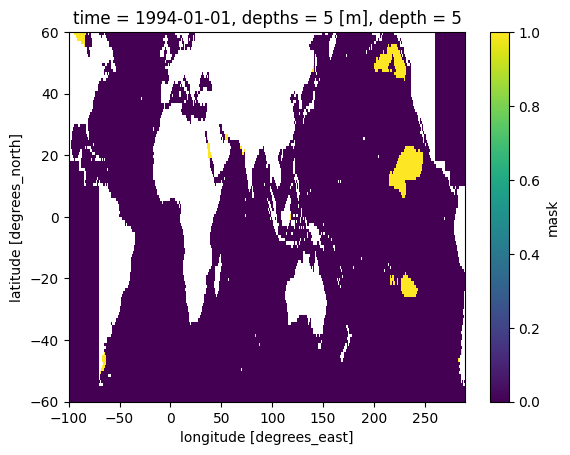

In [48]:
# mhw_3dmask_full = extend_map_and_mask_repeated_area(mhw_3dmask) #This step is to extend the MHW mask data within 100W-70W for later circular tracking

#If your data is not global, you may need 
mhw_3dmask_full = mhw_3dmask 

## Load all previous MHW tracks (from the initial time step)

My initial time is 1993-January

In [29]:
# Load the MHW track data from previous year. If this is the initial year, then no load needed.
if month_count ==0:
    oldsearch = []
    oldtracks = []
else:
    oldtrackfile = folderpath+"globalMHW_track_199301to"+str(end_year-1)+"12"+newtrack_output[-53:] 
    oldsearchfile = folderpath+"globalMHW_search_199301_to"+str(end_year-1)+"12"+newtrack_output[-53:] 

    oldsearch, oldtracks = read_old_MHW_tracks_and_search_from_txtfile(oldtrackfile, oldsearchfile) # search: unfinished MHW tracks. tracks: all finised MHW tracks in previous years.

tracks:  7
search:  6


## Main function 

In [51]:
# Calculate the 4D dimension sizes
latitudes = mhw_3dmask_full.lat.values
Extlongitudes = mhw_3dmask_full.lon.values
depths = mhw_3dmask_full.depth.values
print(mhw_3dmask_full.shape) # time, depth, lat, lon

(12, 200, 120, 390)


In [52]:
# Calculatet the indice of initial month in time series. 1993 is the initical year.
month_count = (start_year - 1993)*12
print(month_count)

12


In [42]:
# Main function 
newsearch, newtracks = main1(start_year, end_year, mhw_3dmask_full, Extlongitudes, latitudes, depths, alpha, cut_off, judgement,oldsearch, oldtracks,month_count,threshold)

current_year:  1994
Identifying MHW objects analysis start.
month order 23
MHWs around 70W are connected! West: [1] East: [4] → new label: 1
month order 23
MHWs around 70W are connected! West: [6] East: [7] → new label: 6
Initial Total labels: 200
Updated Total labels: 198
tracking analysis start.
month:  12
month 24
6  MHW tracks, after reducing the MHWs overlapped with those in the previous month.
4 MHWs are formed from previous MHWs, with0 merged and 4 splitted.
10  MHW tracks, after adding the tracks of  4  newly occurring MHWs.
8  MHW tracks, after removing the tracks of  2  completed MHWs.

 mhw tracking time:  0.7381153106689453
month:  13
month 25
8  MHW tracks, after reducing the MHWs overlapped with those in the previous month.
4 MHWs are formed from previous MHWs, with0 merged and 4 splitted.
10  MHW tracks, after adding the tracks of  2  newly occurring MHWs.
6  MHW tracks, after removing the tracks of  4  completed MHWs.

 mhw tracking time:  0.7403628826141357
month:  14


In [43]:
print(len(newsearch),len(newtracks))

10 16


In [ ]:
# Write the current year track and on-going track (search) list into .txt file
with open(newtrack_output+'.txt', 'w') as f:
    for item in newtracks:
        f.write(str(item)+"\n")

with open(newsearch_output+'.txt', 'w') as f:
    for item in newsearch:
        f.write(str(item)+"\n")


## Visualize tracks (on longitude-latitude plane)

In [44]:
## Load the ocean-land mask data
ocean3dmask = xr.open_dataarray('/g/data/ng72/sz2492/chapt3_evolution/global_study/Data/global_ocean_3dmask_from_60S_to_60N.nc')

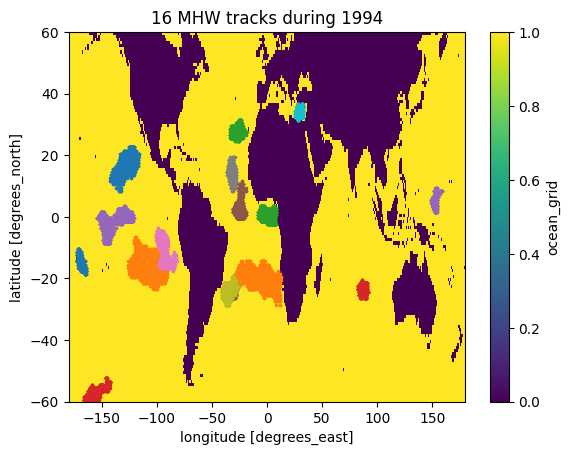

In [46]:
import matplotlib.pyplot as plt
ocean3dmask[0].plot()
monthnum = 0 # the first time step of each MHW track
data = newtracks
for i in range(len(data)):#
    ind =i
    lon1 = Extlongitudes[np.array(data[ind]['xloc'][monthnum]).flatten()]
    lon1[lon1 > 180] -= 360
    #print(i, len(data[ind]['xloc'][monthnum]))
    lat1 = mhw_3dmask_full.lat[np.array(data[ind]['yloc'][monthnum]).flatten()].values
    depth1 = mhw_3dmask_full.depth[np.array(data[ind]['zloc'][monthnum]).flatten()].values
    plt.scatter(lon1,lat1,s=2)
    plt.title(f"{len(newtracks)} MHW tracks during {start_year}")